In [3]:
install.packages("tidyverse")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [5]:
hotel_data <- read.csv("hotel_bookings.csv")

In [6]:
head(hotel_data)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,⋯,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
,<chr>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>
1,Resort Hotel,0,342,2015,July,27,1,0,0,2,⋯,No Deposit,NULL,NULL,0,Transient,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,737,2015,July,27,1,0,0,2,⋯,No Deposit,NULL,NULL,0,Transient,0,0,0,Check-Out,2015-07-01
3,Resort Hotel,0,7,2015,July,27,1,0,1,1,⋯,No Deposit,NULL,NULL,0,Transient,75,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,13,2015,July,27,1,0,1,1,⋯,No Deposit,304,NULL,0,Transient,75,0,0,Check-Out,2015-07-02
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,⋯,No Deposit,240,NULL,0,Transient,98,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,14,2015,July,27,1,0,2,2,⋯,No Deposit,240,NULL,0,Transient,98,0,1,Check-Out,2015-07-03


In [7]:
dim(hotel_data)

[1] 119390     32

In [8]:
names(hotel_data)

[1] "hotel"                          "is_canceled"                   
 [3] "lead_time"                      "arrival_date_year"             
 [5] "arrival_date_month"             "arrival_date_week_number"      
 [7] "arrival_date_day_of_month"      "stays_in_weekend_nights"       
 [9] "stays_in_week_nights"           "adults"                        
[11] "children"                       "babies"                        
[13] "meal"                           "country"                       
[15] "market_segment"                 "distribution_channel"          
[17] "is_repeated_guest"              "previous_cancellations"        
[19] "previous_bookings_not_canceled" "reserved_room_type"            
[21] "assigned_room_type"             "booking_changes"               
[23] "deposit_type"                   "agent"                         
[25] "company"                        "days_in_waiting_list"          
[27] "customer_type"                  "adr"                           
[29] "required_car_parking_spaces"    "total_of_special_requests"     
[31] "reservation_status"             "reservation_status_date"

In [9]:
str(hotel_data)

'data.frame':	119390 obs. of  32 variables:
 $ hotel                         : chr  "Resort Hotel" "Resort Hotel" "Resort Hotel" "Resort Hotel" ...
 $ is_canceled                   : int  0 0 0 0 0 0 0 0 1 1 ...
 $ lead_time                     : int  342 737 7 13 14 14 0 9 85 75 ...
 $ arrival_date_year             : int  2015 2015 2015 2015 2015 2015 2015 2015 2015 2015 ...
 $ arrival_date_month            : chr  "July" "July" "July" "July" ...
 $ arrival_date_week_number      : int  27 27 27 27 27 27 27 27 27 27 ...
 $ arrival_date_day_of_month     : int  1 1 1 1 1 1 1 1 1 1 ...
 $ stays_in_weekend_nights       : int  0 0 0 0 0 0 0 0 0 0 ...
 $ stays_in_week_nights          : int  0 0 1 1 2 2 2 2 3 3 ...
 $ adults                        : int  2 2 1 1 2 2 2 2 2 2 ...
 $ children                      : int  0 0 0 0 0 0 0 0 0 0 ...
 $ babies                        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ meal                          : chr  "BB" "BB" "BB" "BB" ...
 $ country                 

In [10]:
summary(hotel_data)

       hotel         is_canceled       lead_time   arrival_date_year
 Length   :119390   Min.   :0.0000   Min.   :  0   Min.   :2015     
 N.unique :     2   1st Qu.:0.0000   1st Qu.: 18   1st Qu.:2016     
 N.blank  :     0   Median :0.0000   Median : 69   Median :2016     
 Min.nchar:    10   Mean   :0.3704   Mean   :104   Mean   :2016     
 Max.nchar:    12   3rd Qu.:1.0000   3rd Qu.:160   3rd Qu.:2017     
                    Max.   :1.0000   Max.   :737   Max.   :2017     
                                                                    
 arrival_date_month arrival_date_week_number arrival_date_day_of_month
 Length   :119390   Min.   : 1.00            Min.   : 1.0             
 N.unique :    12   1st Qu.:16.00            1st Qu.: 8.0             
 N.blank  :     0   Median :28.00            Median :16.0             
 Min.nchar:     3   Mean   :27.17            Mean   :15.8             
 Max.nchar:     9   3rd Qu.:38.00            3rd Qu.:23.0             
                    Ma

In [11]:
colSums(is.na(hotel_data))

hotel                    is_canceled 
                             0                              0 
                     lead_time              arrival_date_year 
                             0                              0 
            arrival_date_month       arrival_date_week_number 
                             0                              0 
     arrival_date_day_of_month        stays_in_weekend_nights 
                             0                              0 
          stays_in_week_nights                         adults 
                             0                              0 
                      children                         babies 
                             4                              0 
                          meal                        country 
                             0                              0 
                market_segment           distribution_channel 
                             0                              0 
             is_repeated_guest         previous_cancellations 
                             0                              0 
previous_bookings_not_canceled             reserved_room_type 
                             0                              0 
            assigned_room_type                booking_changes 
                             0                              0 
                  deposit_type                          agent 
                             0                              0 
                       company           days_in_waiting_list 
                             0                              0 
                 customer_type                            adr 
                             0                              0 
   required_car_parking_spaces      total_of_special_requests 
                             0                              0 
            reservation_status        reservation_status_date 
                             0                              0

In [12]:
unique(hotel_data$country)

[1] "PRT"  "GBR"  "USA"  "ESP"  "IRL"  "FRA"  "NULL" "ROU"  "NOR"  "OMN" 
 [11] "ARG"  "POL"  "DEU"  "BEL"  "CHE"  "CN"   "GRC"  "ITA"  "NLD"  "DNK" 
 [21] "RUS"  "SWE"  "AUS"  "EST"  "CZE"  "BRA"  "FIN"  "MOZ"  "BWA"  "LUX" 
 [31] "SVN"  "ALB"  "IND"  "CHN"  "MEX"  "MAR"  "UKR"  "SMR"  "LVA"  "PRI" 
 [41] "SRB"  "CHL"  "AUT"  "BLR"  "LTU"  "TUR"  "ZAF"  "AGO"  "ISR"  "CYM" 
 [51] "ZMB"  "CPV"  "ZWE"  "DZA"  "KOR"  "CRI"  "HUN"  "ARE"  "TUN"  "JAM" 
 [61] "HRV"  "HKG"  "IRN"  "GEO"  "AND"  "GIB"  "URY"  "JEY"  "CAF"  "CYP" 
 [71] "COL"  "GGY"  "KWT"  "NGA"  "MDV"  "VEN"  "SVK"  "FJI"  "KAZ"  "PAK" 
 [81] "IDN"  "LBN"  "PHL"  "SEN"  "SYC"  "AZE"  "BHR"  "NZL"  "THA"  "DOM" 
 [91] "MKD"  "MYS"  "ARM"  "JPN"  "LKA"  "CUB"  "CMR"  "BIH"  "MUS"  "COM" 
[101] "SUR"  "UGA"  "BGR"  "CIV"  "JOR"  "SYR"  "SGP"  "BDI"  "SAU"  "VNM" 
[111] "PLW"  "QAT"  "EGY"  "PER"  "MLT"  "MWI"  "ECU"  "MDG"  "ISL"  "UZB" 
[121] "NPL"  "BHS"  "MAC"  "TGO"  "TWN"  "DJI"  "STP"  "KNA"  "ETH"  "IRQ" 
[131] "HND"  "RWA"  "KHM"  "MCO"  "BGD"  "IMN"  "TJK"  "NIC"  "BEN"  "VGB" 
[141] "TZA"  "GAB"  "GHA"  "TMP"  "GLP"  "KEN"  "LIE"  "GNB"  "MNE"  "UMI" 
[151] "MYT"  "FRO"  "MMR"  "PAN"  "BFA"  "LBY"  "MLI"  "NAM"  "BOL"  "PRY" 
[161] "BRB"  "ABW"  "AIA"  "SLV"  "DMA"  "PYF"  "GUY"  "LCA"  "ATA"  "GTM" 
[171] "ASM"  "MRT"  "NCL"  "KIR"  "SDN"  "ATF"  "SLE"  "LAO"

In [13]:
unique(hotel_data$agent)

[1] "NULL" "304"  "240"  "303"  "15"   "241"  "8"    "250"  "115"  "5"   
 [11] "175"  "134"  "156"  "243"  "242"  "3"    "105"  "40"   "147"  "306" 
 [21] "184"  "96"   "2"    "127"  "95"   "146"  "9"    "177"  "6"    "143" 
 [31] "244"  "149"  "167"  "300"  "171"  "305"  "67"   "196"  "152"  "142" 
 [41] "261"  "104"  "36"   "26"   "29"   "258"  "110"  "71"   "181"  "88"  
 [51] "251"  "275"  "69"   "248"  "208"  "256"  "314"  "126"  "281"  "273" 
 [61] "253"  "185"  "330"  "334"  "328"  "326"  "321"  "324"  "313"  "38"  
 [71] "155"  "68"   "335"  "308"  "332"  "94"   "348"  "310"  "339"  "375" 
 [81] "66"   "327"  "387"  "298"  "91"   "245"  "385"  "257"  "393"  "168" 
 [91] "405"  "249"  "315"  "75"   "128"  "307"  "11"   "436"  "1"    "201" 
[101] "183"  "223"  "368"  "336"  "291"  "464"  "411"  "481"  "10"   "154" 
[111] "468"  "410"  "390"  "440"  "495"  "492"  "493"  "434"  "57"   "531" 
[121] "420"  "483"  "526"  "472"  "429"  "16"   "446"  "34"   "78"   "139" 
[131] "252"  "270"  "47"   "114"  "301"  "193"  "182"  "135"  "350"  "195" 
[141] "352"  "355"  "159"  "363"  "384"  "360"  "331"  "367"  "64"   "406" 
[151] "163"  "414"  "333"  "427"  "431"  "430"  "426"  "438"  "433"  "418" 
[161] "441"  "282"  "432"  "72"   "450"  "180"  "454"  "455"  "59"   "451" 
[171] "254"  "358"  "469"  "165"  "467"  "510"  "337"  "476"  "502"  "527" 
[181] "479"  "508"  "535"  "302"  "497"  "187"  "13"   "7"    "27"   "14"  
[191] "22"   "17"   "28"   "42"   "20"   "19"   "45"   "37"   "61"   "39"  
[201] "21"   "24"   "41"   "50"   "30"   "54"   "52"   "12"   "44"   "31"  
[211] "83"   "32"   "63"   "60"   "55"   "56"   "89"   "87"   "118"  "86"  
[221] "85"   "210"  "214"  "129"  "179"  "138"  "174"  "170"  "153"  "93"  
[231] "151"  "119"  "35"   "173"  "58"   "53"   "133"  "79"   "235"  "192" 
[241] "191"  "236"  "162"  "215"  "157"  "287"  "132"  "234"  "98"   "77"  
[251] "103"  "107"  "262"  "220"  "121"  "205"  "378"  "23"   "296"  "290" 
[261] "229"  "33"   "286"  "276"  "425"  "484"  "323"  "403"  "219"  "394" 
[271] "509"  "111"  "423"  "4"    "70"   "82"   "81"   "74"   "92"   "99"  
[281] "90"   "112"  "117"  "106"  "148"  "158"  "144"  "211"  "213"  "216" 
[291] "232"  "150"  "267"  "227"  "247"  "278"  "280"  "285"  "289"  "269" 
[301] "295"  "265"  "288"  "122"  "294"  "325"  "341"  "344"  "346"  "359" 
[311] "283"  "364"  "370"  "371"  "25"   "141"  "391"  "397"  "416"  "404" 
[321] "299"  "197"  "73"   "354"  "444"  "408"  "461"  "388"  "453"  "459" 
[331] "474"  "475"  "480"  "449"

In [14]:
unique(hotel_data$company)

[1] "NULL" "110"  "113"  "270"  "178"  "240"  "154"  "144"  "307"  "268" 
 [11] "59"   "204"  "312"  "318"  "94"   "174"  "274"  "195"  "223"  "317" 
 [21] "281"  "118"  "53"   "286"  "12"   "47"   "324"  "342"  "373"  "371" 
 [31] "383"  "86"   "82"   "218"  "88"   "31"   "397"  "392"  "405"  "331" 
 [41] "367"  "20"   "83"   "416"  "51"   "395"  "102"  "34"   "84"   "360" 
 [51] "394"  "457"  "382"  "461"  "478"  "386"  "112"  "486"  "421"  "9"   
 [61] "308"  "135"  "224"  "504"  "269"  "356"  "498"  "390"  "513"  "203" 
 [71] "263"  "477"  "521"  "169"  "515"  "445"  "337"  "251"  "428"  "292" 
 [81] "388"  "130"  "250"  "355"  "254"  "543"  "531"  "528"  "62"   "120" 
 [91] "42"   "81"   "116"  "530"  "103"  "39"   "16"   "92"   "61"   "501" 
[101] "165"  "291"  "290"  "43"   "325"  "192"  "108"  "200"  "465"  "287" 
[111] "297"  "490"  "482"  "207"  "282"  "437"  "225"  "329"  "272"  "28"  
[121] "77"   "338"  "72"   "246"  "319"  "146"  "159"  "380"  "323"  "511" 
[131] "407"  "278"  "80"   "403"  "399"  "14"   "137"  "343"  "346"  "347" 
[141] "349"  "289"  "351"  "353"  "54"   "99"   "358"  "361"  "362"  "366" 
[151] "372"  "365"  "277"  "109"  "377"  "379"  "22"   "378"  "330"  "364" 
[161] "401"  "232"  "255"  "384"  "167"  "212"  "514"  "391"  "400"  "376" 
[171] "402"  "396"  "302"  "398"  "6"    "370"  "369"  "409"  "168"  "104" 
[181] "408"  "413"  "148"  "10"   "333"  "419"  "415"  "424"  "425"  "423" 
[191] "422"  "435"  "439"  "442"  "448"  "443"  "454"  "444"  "52"   "459" 
[201] "458"  "456"  "460"  "447"  "470"  "466"  "484"  "184"  "485"  "32"  
[211] "487"  "491"  "494"  "193"  "516"  "496"  "499"  "29"   "78"   "520" 
[221] "507"  "506"  "512"  "126"  "64"   "242"  "518"  "523"  "539"  "534" 
[231] "436"  "525"  "541"  "40"   "455"  "410"  "45"   "38"   "49"   "48"  
[241] "67"   "68"   "65"   "91"   "37"   "8"    "179"  "209"  "219"  "221" 
[251] "227"  "153"  "186"  "253"  "202"  "216"  "275"  "233"  "280"  "309" 
[261] "321"  "93"   "316"  "85"   "107"  "350"  "279"  "334"  "348"  "150" 
[271] "73"   "385"  "418"  "197"  "450"  "452"  "115"  "46"   "76"   "96"  
[281] "100"  "105"  "101"  "122"  "11"   "139"  "142"  "127"  "143"  "140" 
[291] "149"  "163"  "160"  "180"  "238"  "183"  "222"  "185"  "217"  "215" 
[301] "213"  "237"  "230"  "234"  "35"   "245"  "158"  "258"  "259"  "260" 
[311] "411"  "257"  "271"  "18"   "106"  "210"  "273"  "71"   "284"  "301" 
[321] "305"  "293"  "264"  "311"  "304"  "313"  "288"  "320"  "314"  "332" 
[331] "341"  "352"  "243"  "368"  "393"  "132"  "220"  "412"  "420"  "426" 
[341] "417"  "429"  "433"  "446"  "357"  "479"  "483"  "489"  "229"  "481" 
[351] "497"  "451"  "492"

In [15]:
sum(is.na(hotel_data))

[1] 4

In [16]:
table(hotel_data$country == "NULL")


 FALSE   TRUE 
118902    488 

In [17]:
sum(is.na(hotel_data$country))

[1] 0

In [18]:
dim(hotel_data)

[1] 119390     32

In [19]:
hotel_data[hotel_data == "NULL"] <- NA

In [20]:
colSums(is.na(hotel_data))

hotel                    is_canceled 
                             0                              0 
                     lead_time              arrival_date_year 
                             0                              0 
            arrival_date_month       arrival_date_week_number 
                             0                              0 
     arrival_date_day_of_month        stays_in_weekend_nights 
                             0                              0 
          stays_in_week_nights                         adults 
                             0                              0 
                      children                         babies 
                             4                              0 
                          meal                        country 
                             0                            488 
                market_segment           distribution_channel 
                             0                              0 
             is_repeated_guest         previous_cancellations 
                             0                              0 
previous_bookings_not_canceled             reserved_room_type 
                             0                              0 
            assigned_room_type                booking_changes 
                             0                              0 
                  deposit_type                          agent 
                             0                          16340 
                       company           days_in_waiting_list 
                        112593                              0 
                 customer_type                            adr 
                             0                              0 
   required_car_parking_spaces      total_of_special_requests 
                             0                              0 
            reservation_status        reservation_status_date 
                             0                              0

TO REMOVE NULL VALUES

In [21]:
hotel_data <- hotel_data[!is.na(hotel_data$children), ]

In [24]:
hotel_data$country[is.na(hotel_data$country)] <- "Unknown"

In [25]:
hotel_data$agent[is.na(hotel_data$agent)] <- 0

In [26]:
hotel_data$company <- NULL

In [27]:
colSums(is.na(hotel_data))

hotel                    is_canceled 
                             0                              0 
                     lead_time              arrival_date_year 
                             0                              0 
            arrival_date_month       arrival_date_week_number 
                             0                              0 
     arrival_date_day_of_month        stays_in_weekend_nights 
                             0                              0 
          stays_in_week_nights                         adults 
                             0                              0 
                      children                         babies 
                             0                              0 
                          meal                        country 
                             0                              0 
                market_segment           distribution_channel 
                             0                              0 
             is_repeated_guest         previous_cancellations 
                             0                              0 
previous_bookings_not_canceled             reserved_room_type 
                             0                              0 
            assigned_room_type                booking_changes 
                             0                              0 
                  deposit_type                          agent 
                             0                              0 
          days_in_waiting_list                  customer_type 
                             0                              0 
                           adr    required_car_parking_spaces 
                             0                              0 
     total_of_special_requests             reservation_status 
                             0                              0 
       reservation_status_date 
                             0

Outlier Detection

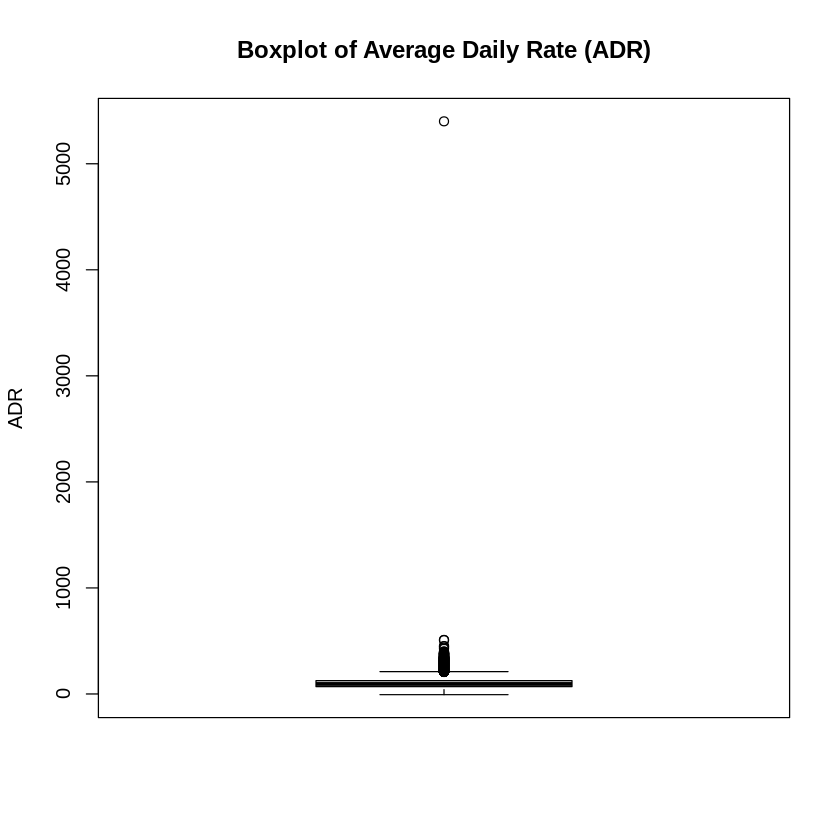

In [28]:
boxplot(hotel_data$adr,
        main = "Boxplot of Average Daily Rate (ADR)",
        ylab = "ADR")

Detect Outliers Using the IQR Method



In [29]:
Q1 <- quantile(hotel_data$adr, 0.25)
Q3 <- quantile(hotel_data$adr, 0.75)

IQR_value <- IQR(hotel_data$adr)

lower_limit <- Q1 - 1.5 * IQR_value
upper_limit <- Q3 + 1.5 * IQR_value

lower_limit
upper_limit

25% 
-15.775

75% 
211.065

Count the Outliers

In [30]:
sum(hotel_data$adr < lower_limit | hotel_data$adr > upper_limit)

[1] 3793

Remove the Outliers

In [31]:
hotel_data <- hotel_data[
  hotel_data$adr >= lower_limit &
  hotel_data$adr <= upper_limit,
]

Verifying

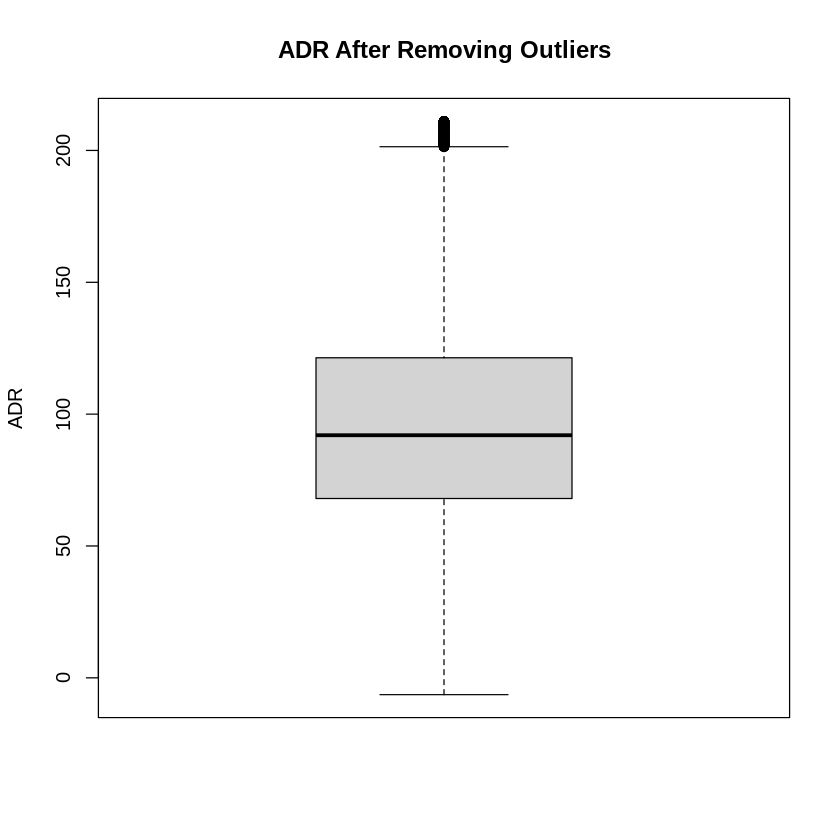

In [32]:
boxplot(
  hotel_data$adr,
  main = "ADR After Removing Outliers",
  ylab = "ADR"
)

Normalization

In [33]:
hotel_data$adr_normalized <- (hotel_data$adr - min(hotel_data$adr)) /  (max(hotel_data$adr) - min(hotel_data$adr))

Verifying

In [34]:
summary(hotel_data$adr_normalized)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.3421  0.4525  0.4757  0.5876  1.0000 

Encoding Categorical Variables

In [35]:
table(hotel_data$hotel)


  City Hotel Resort Hotel 
       78036        37557 

In [36]:
hotel_data$hotel <- as.factor(hotel_data$hotel)

Verifying

In [37]:
str(hotel_data$hotel)

 Factor w/ 2 levels "City Hotel","Resort Hotel": 2 2 2 2 2 2 2 2 2 2 ...


Exploratory Data Analysis (EDA)

Graph 1: Hotel Type Distribution (Bar Chart)

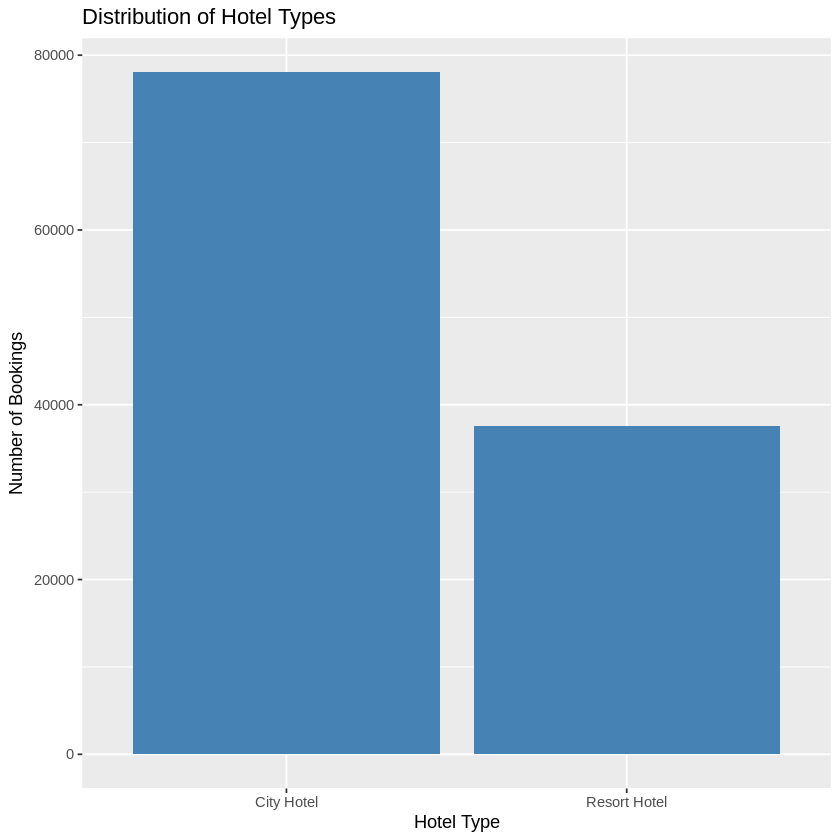

In [38]:
ggplot(hotel_data, aes(x = hotel)) +
  geom_bar(fill = "steelblue") +
  labs(
    title = "Distribution of Hotel Types",
    x = "Hotel Type",
    y = "Number of Bookings"
  )

Graph 2 : Distribution of ADR (Histogram)

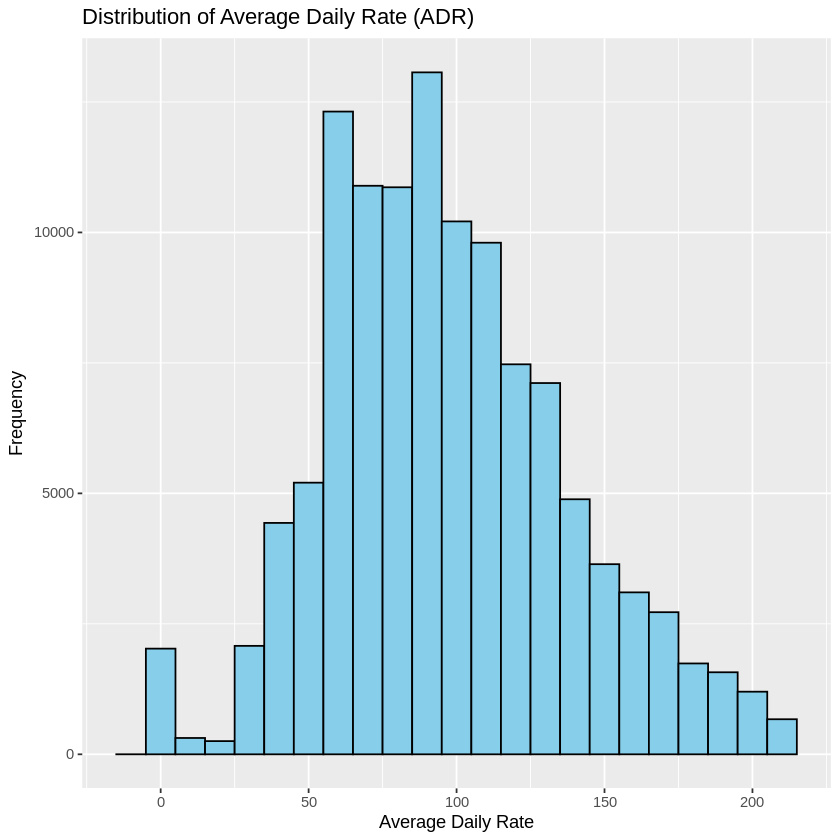

In [41]:
ggplot(hotel_data, aes(x = adr)) +
  geom_histogram(binwidth = 10, fill = "skyblue", color = "black") +
  labs(
    title = "Distribution of Average Daily Rate (ADR)",
    x = "Average Daily Rate",
    y = "Frequency"
  )

Graph 3 : Cancellation Analysis

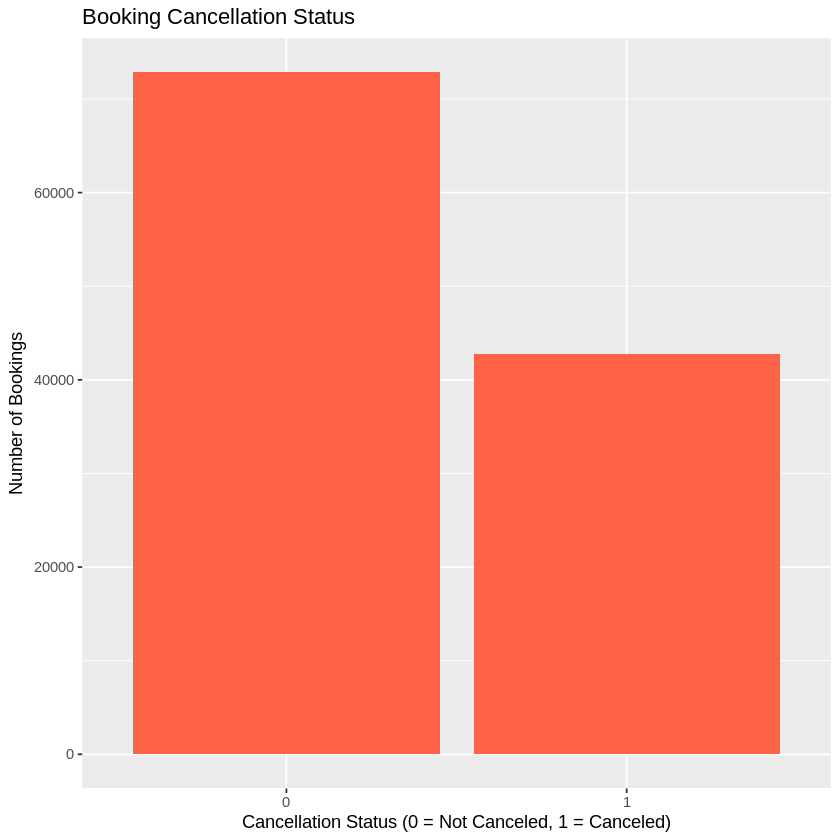

In [43]:
ggplot(hotel_data, aes(x = factor(is_canceled))) +
  geom_bar(fill = "tomato") +
  labs(
    title = "Booking Cancellation Status", x = "Cancellation Status (0 = Not Canceled, 1 = Canceled)", y = "Number of Bookings"
  )

Correlation Analysis

In [44]:
numeric_data <- hotel_data[sapply(hotel_data, is.numeric)]

correlation_matrix <- cor(numeric_data)

round(correlation_matrix, 2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,adr_normalized
is_canceled,1.00,0.30,0.01,0.01,-0.01,-0.01,0.02,0.06,0.00,-0.03,-0.08,0.11,-0.06,-0.14,0.06,0.06,-0.19,-0.23,0.06
lead_time,0.30,1.00,0.04,0.13,0.00,0.08,0.17,0.13,-0.03,-0.02,-0.13,0.09,-0.07,0.00,0.17,-0.04,-0.12,-0.10,-0.04
arrival_date_year,0.01,0.04,1.00,-0.55,0.00,0.02,0.03,0.02,0.03,-0.01,0.01,-0.12,0.03,0.03,-0.05,0.19,-0.02,0.10,0.19
arrival_date_week_number,0.01,0.13,-0.55,1.00,0.06,0.02,0.01,0.02,0.00,0.01,-0.03,0.04,-0.02,0.00,0.02,0.06,0.00,0.02,0.06
arrival_date_day_of_month,-0.01,0.00,0.00,0.06,1.00,-0.02,-0.03,0.00,0.01,0.00,-0.01,-0.03,0.00,0.01,0.02,0.03,0.01,0.00,0.03
stays_in_weekend_nights,-0.01,0.08,0.02,0.02,-0.02,1.00,0.50,0.09,0.04,0.02,-0.09,-0.01,-0.04,0.06,-0.05,0.04,-0.02,0.07,0.04
stays_in_week_nights,0.02,0.17,0.03,0.01,-0.03,0.50,1.00,0.09,0.04,0.02,-0.10,-0.01,-0.05,0.10,0.00,0.05,-0.03,0.07,0.05
adults,0.06,0.13,0.02,0.02,0.00,0.09,0.09,1.00,0.02,0.02,-0.15,0.00,-0.11,-0.06,-0.01,0.23,0.01,0.12,0.23
children,0.00,-0.03,0.03,0.00,0.01,0.04,0.04,0.02,1.00,0.03,-0.03,-0.02,-0.02,0.05,-0.03,0.24,0.05,0.09,0.24
babies,-0.03,-0.02,-0.01,0.01,0.00,0.02,0.02,0.02,0.03,1.00,-0.01,-0.01,-0.01,0.08,-0.01,0.02,0.03,0.09,0.02
